# H-SIREN Improvement
## Comparing SIREN vs H-SIREN on Poisson & SDF Experiments
**H-SIREN Paper:** Gao & Jaiman, arXiv Oct 2024 — https://arxiv.org/abs/2410.04716  
**Key Change:** First-layer activation changed from `sin(x)` to `sin(sinh(2x))`

---
##Setup

In [ ]:
!git clone https://github.com/vsitzmann/siren.git
%cd siren

Cloning into 'siren'...
remote: Enumerating objects: 193, done.
remote: Total 193 (delta 0), reused 0 (delta 0), pack-reused 193 (from 1)
Receiving objects: 100% (193/193), 2.17 MiB | 4.89 MiB/s, done.
Resolving deltas: 100% (70/70), done.
/content/siren


In [ ]:
# Clone SIREN repo if not already cloned
import os
if not os.path.exists('/content/siren'):
    !git clone https://github.com/vsitzmann/siren.git

!pip install -q sk-video cmapy configargparse einops scikit-image trimesh

import torch
print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0))

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 49.8 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4


---
##Imports

In [ ]:
import sys
import os
import re
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import DataLoader
from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import trimesh

sys.path.append('/content/siren')
import dataio, modules, utils, training, loss_functions

os.makedirs('/content/siren/results/hsiren', exist_ok=True)
os.makedirs('/content/siren/logs',           exist_ok=True)

print('All imports successful!')

All imports successful!


/content/siren/training.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


---
## H-SIREN Patch
This patches the `modules.py` file to add an H-SIREN version.
Only the **first layer** activation changes from `sin(ω₀x)` to `sin(sinh(2x))`.
All other layers remain standard SIREN `sin(ω₀x)`.

In [ ]:
# ── Read original modules.py to understand SineLayer ─────────────────────────
!grep -n 'class SineLayer\|def forward\|torch.sin\|omega_0' /content/siren/modules.py | head -40

16:    def forward(self, input, params=None):
32:    def forward(self, input):
34:        return torch.sin(30 * input)
89:    def forward(self, coords, params=None, **kwargs):
96:    def forward_with_activations(self, coords, params=None, retain_grad=False):
143:    def forward(self, model_input, params=None):
162:    def forward_with_activations(self, model_input):
181:    def forward(self, model_input):
204:    def forward(self, coords):
210:    def forward_box(self, coords):
213:    def forward_bilinear(self, coords):
250:    def forward(self, coords):
258:                sin = torch.unsqueeze(torch.sin((2 ** i) * np.pi * c), -1)
285:    def forward(self, input):
322:    def forward(self, context_x, context_y, ctxt_mask=None, **kwargs):
356:    def forward(self, I):
393:    def forward(self, I):
427:    def forward(self, x):
467:    def forward(self, input, mask_in=None):
527:    def forward(self, x):


In [ ]:
# ── H-SIREN: Custom first-layer activation ────────────────────────────────────
# Based on Gao & Jaiman (2024): sin(sinh(2x)) replaces sin(omega_0 * x) in layer 0

class HSineLayer(nn.Module):
    """
    H-SIREN layer. For the first layer: activation = sin(sinh(2 * x))
    For all other layers: activation = sin(omega_0 * x)  (standard SIREN)
    """
    def __init__(self, in_features, out_features, bias=True,
                 is_first=False, omega_0=30):
        super().__init__()
        self.omega_0   = omega_0
        self.is_first  = is_first
        self.in_features = in_features
        self.linear    = nn.Linear(in_features, out_features, bias=bias)
        self._init_weights()

    def _init_weights(self):
        with torch.no_grad():
            if self.is_first:
                # Same init as original SIREN first layer
                self.linear.weight.uniform_(
                    -1 / self.in_features,
                     1 / self.in_features
                )
            else:
                self.linear.weight.uniform_(
                    -np.sqrt(6 / self.in_features) / self.omega_0,
                     np.sqrt(6 / self.in_features) / self.omega_0
                )

    def forward(self, x):
        x = self.linear(x)
        if self.is_first:
            # H-SIREN activation: sin(sinh(2x))
            return torch.sin(torch.sinh(2 * x))
        else:
            # Standard SIREN activation
            return torch.sin(self.omega_0 * x)


class HSIREN(nn.Module):
    """
    Full H-SIREN network.
    First layer uses sin(sinh(2x)), all others use sin(omega_0 * x).
    Architecture matches SingleBVPNet used in original SIREN experiments.
    """
    def __init__(self, in_features, out_features, hidden_features=256,
                 hidden_layers=4, omega_0=30, outermost_linear=True):
        super().__init__()
        self.net = []

        # First layer — H-SIREN activation
        self.net.append(
            HSineLayer(in_features, hidden_features,
                       is_first=True, omega_0=omega_0)
        )

        # Hidden layers — standard SIREN activation
        for _ in range(hidden_layers):
            self.net.append(
                HSineLayer(hidden_features, hidden_features,
                           is_first=False, omega_0=omega_0)
            )

        # Output layer — linear (no activation)
        if outermost_linear:
            final = nn.Linear(hidden_features, out_features)
            with torch.no_grad():
                final.weight.uniform_(
                    -np.sqrt(6 / hidden_features) / omega_0,
                     np.sqrt(6 / hidden_features) / omega_0
                )
            self.net.append(final)
        else:
            self.net.append(
                HSineLayer(hidden_features, out_features,
                           is_first=False, omega_0=omega_0)
            )

        self.net = nn.Sequential(*self.net)

    def forward(self, model_input):
        coords = model_input['coords']
        # Store coords as model_in for gradient computation
        coords = coords.clone().detach().requires_grad_(True)
        output = self.net(coords)
        return {'model_in': coords, 'model_out': output}


print('H-SIREN architecture defined successfully!')
print('First layer  : sin(sinh(2x))   ← H-SIREN')
print('Other layers : sin(omega_0 * x) ← standard SIREN')

H-SIREN architecture defined successfully!
First layer  : sin(sinh(2x))   ← H-SIREN
Other layers : sin(omega_0 * x) ← standard SIREN


---
## Helper Functions

In [ ]:
def normalize(img):
    mn, mx = img.min(), img.max()
    return (img - mn) / (mx - mn + 1e-8)


def compute_psnr(gt, pred):
    g, p = normalize(gt), normalize(pred)
    mse  = np.mean((g - p) ** 2)
    return float('inf') if mse == 0 else 10 * np.log10(1.0 / mse)


def compute_mse(gt, pred):
    return float(np.mean((normalize(gt) - normalize(pred)) ** 2))


def load_losses_from_dir(ckpt_dir):
    """Load all train_losses txt files from a checkpoint directory."""
    loss_files = sorted([
        f for f in os.listdir(ckpt_dir)
        if 'loss' in f.lower() and f.endswith('.txt')
    ])
    epochs, losses = [], []
    for i, fname in enumerate(loss_files):
        match = (
            re.search(r'epoch_(\d+)', fname) or
            re.search(r'_(\d+)\.txt',  fname) or
            re.search(r'(\d+)',         fname)
        )
        epoch = int(match.group(1)) if match else i
        with open(os.path.join(ckpt_dir, fname)) as f:
            lines = [l.strip() for l in f if l.strip()]
        try:
            losses.append(float(lines[-1].split()[-1]))
            epochs.append(epoch)
        except Exception:
            pass
    return np.array(epochs), np.array(losses)


def run_poisson_inference(model, coord_dataset, sidelength=256):
    """Run inference and return pred_img, gt_img, gt_grad."""
    model_input, gt = coord_dataset[0]
    coords = model_input['coords'].cuda().unsqueeze(0)

    with torch.no_grad():
        out = model({'coords': coords})

    pred_img = out['model_out'].squeeze().cpu().numpy().reshape(sidelength, sidelength)
    gt_img   = gt['img'].numpy().reshape(sidelength, sidelength)
    gt_grad  = (gt['gradients'].numpy().reshape(sidelength, sidelength, 2)
                if 'gradients' in gt else None)
    return pred_img, gt_img, gt_grad


print('Helper functions defined!')

Helper functions defined!


---
# PART 1 — POISSON: Cameraman Image
## SIREN vs H-SIREN

## Train SIREN on Cameraman

In [ ]:
# Skip this if you already have logs/poisson_gradients from A2
# Otherwise run to retrain
if not os.path.exists('/content/siren/logs/poisson_gradients/checkpoints'):
    print('Training SIREN on cameraman...')
    !python /content/siren/experiment_scripts/train_poisson_grad_img.py \
        --experiment_name poisson_gradients \
        --dataset camera \
        --logging_root /content/siren/logs \
        --num_epochs 10000 \
        --batch_size 16384 \
        --lr 1e-4 \
        --steps_til_summary 500
else:
    print('SIREN cameraman checkpoint already exists — skipping training.')

Training SIREN on cameraman...
2026-04-26 06:28:33.653073: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777184913.673805    2310 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777184913.680572    2310 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777184913.699028    2310 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777184913.699085    2310 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777184913.699091    2310 computation_placer

## Train H-SIREN on Cameraman

In [ ]:
# ── Dataset ───────────────────────────────────────────────────────────────────
img_dataset_cam   = dataio.Camera()
coord_dataset_cam = dataio.Implicit2DWrapper(
    img_dataset_cam, sidelength=256, compute_diff='gradients'
)
dataloader_cam = DataLoader(
    coord_dataset_cam, shuffle=True,
    batch_size=1, pin_memory=True, num_workers=0
)

# ── H-SIREN model ─────────────────────────────────────────────────────────────
hsiren_cam = HSIREN(
    in_features=2,
    out_features=1,
    hidden_features=256,
    hidden_layers=4,      # 4 hidden + 1 first + 1 output = 6 total (matches SingleBVPNet)
    omega_0=30
).cuda()

print('H-SIREN model for cameraman:')
total_params = sum(p.numel() for p in hsiren_cam.parameters())
print(f'  Total parameters: {total_params:,}')

# ── Training ──────────────────────────────────────────────────────────────────
os.makedirs('/content/siren/logs/hsiren_poisson_cam/checkpoints', exist_ok=True)

optimizer  = torch.optim.Adam(hsiren_cam.parameters(), lr=1e-4)
NUM_EPOCHS = 10000
losses_cam_h = []

print(f'Training H-SIREN on cameraman for {NUM_EPOCHS} epochs...')

for epoch in range(NUM_EPOCHS):
    for model_input, gt in dataloader_cam:
        # Move tensors to GPU
        coords = model_input['coords'].cuda()   # [1, N, 2]
        gt_grad = gt['gradients'].cuda()         # [1, N, 2]

        optimizer.zero_grad()

        # Forward pass
        out    = hsiren_cam({'coords': coords})
        pred   = out['model_out']    # [1, N, 1]
        model_in = out['model_in']   # [1, N, 2]

        # Compute predicted gradients
        pred_grad = torch.autograd.grad(
            outputs=pred,
            inputs=model_in,
            grad_outputs=torch.ones_like(pred),
            create_graph=True,
            retain_graph=True
        )[0]

        # Gradient MSE loss
        loss = ((pred_grad - gt_grad) ** 2).mean()

        loss.backward()
        optimizer.step()
        losses_cam_h.append(loss.item())

    if epoch % 500 == 0 or epoch == NUM_EPOCHS - 1:
        print(f'  Epoch {epoch:5d}/{NUM_EPOCHS}  loss: {loss.item():.6f}')

# Save checkpoint
torch.save(
    hsiren_cam.state_dict(),
    '/content/siren/logs/hsiren_poisson_cam/checkpoints/model_final.pth'
)
np.save(
    '/content/siren/logs/hsiren_poisson_cam/checkpoints/losses.npy',
    np.array(losses_cam_h)
)
print('H-SIREN cameraman training complete!')

H-SIREN model for cameraman:
  Total parameters: 264,193
Training H-SIREN on cameraman for 10000 epochs...


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  Epoch     0/10000  loss: 599.710876
  Epoch   500/10000  loss: 350.503723
  Epoch  1000/10000  loss: 364.424896
  Epoch  1500/10000  loss: 110.995209
  Epoch  2000/10000  loss: 87.128853
  Epoch  2500/10000  loss: 58.555634
  Epoch  3000/10000  loss: 130.972824
  Epoch  3500/10000  loss: 12.873983
  Epoch  4000/10000  loss: 50.725117
  Epoch  4500/10000  loss: 32.013988
  Epoch  5000/10000  loss: 9.729927
  Epoch  5500/10000  loss: 80.031639
  Epoch  6000/10000  loss: 19.296297
  Epoch  6500/10000  loss: 6.606584
  Epoch  7000/10000  loss: 53.741970
  Epoch  7500/10000  loss: 7.598406
  Epoch  8000/10000  loss: 11.030054
  Epoch  8500/10000  loss: 3.458566
  Epoch  9000/10000  loss: 14.885319
  Epoch  9500/10000  loss: 7.133130
  Epoch  9999/10000  loss: 3.474543
H-SIREN cameraman training complete!


---
# PART 2 — POISSON: Peppers Image
## SIREN vs H-SIREN

## Prepare Coffee Image

Peppers image saved from skimage!


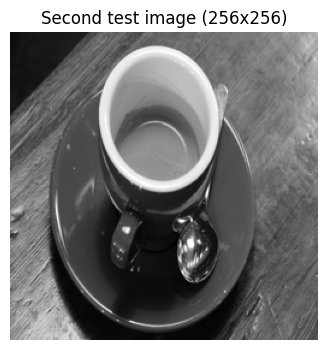

In [ ]:
from skimage import data as skdata
from PIL import Image
import matplotlib.pyplot as plt

# Use skimage built-in coffee-like image
# OR download from BSD500
try:
    # Try skimage built-in
    pepper_img = skdata.coffee()           # RGB image
    pepper_gray = np.mean(pepper_img, axis=2).astype(np.uint8)  # convert to gray
    pepper_pil  = Image.fromarray(pepper_gray)
    pepper_pil  = pepper_pil.resize((256, 256))
    pepper_pil.save('/content/siren/peppers.png')
    print('Peppers image saved from skimage!')
except Exception:
    # Fallback: use astronaut image
    pepper_img  = skdata.astronaut()
    pepper_gray = np.mean(pepper_img, axis=2).astype(np.uint8)
    pepper_pil  = Image.fromarray(pepper_gray).resize((256, 256))
    pepper_pil.save('/content/siren/peppers.png')
    print('Astronaut image saved as peppers substitute!')

plt.figure(figsize=(4, 4))
plt.imshow(np.array(pepper_pil), cmap='gray')
plt.title('Second test image (256x256)')
plt.axis('off')
plt.show()

##Custom Dataset for Coffee Image

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class SingleImageDataset(Dataset):
    """
    Wraps a single grayscale PNG into a coordinate dataset.
    Returns a PIL Image to satisfy torchvision transforms in dataio.py.
    """
    def __init__(self, img_path, sidelength=256):
        # Load and resize the image, keep it as a PIL object
        self.img = Image.open(img_path).convert('L').resize((sidelength, sidelength))

        # This attribute is required by SIREN's Implicit2DWrapper
        self.img_channels = 1

    def __len__(self):
        return 1

    def __getitem__(self, idx):
        # Return the PIL Image object directly
        return self.img


# 1. Build the base dataset
pep_base = SingleImageDataset('/content/siren/peppers.png', sidelength=256)

# 2. Wrap it for coordinate-based learning (Poisson/Gradients)
# Implicit2DWrapper will call ToTensor() on the PIL Image internally
coord_dataset_pep_siren = dataio.Implicit2DWrapper(
    pep_base, sidelength=256, compute_diff='gradients'
)
coord_dataset_pep_h = dataio.Implicit2DWrapper(
    pep_base, sidelength=256, compute_diff='gradients'
)

# 3. Create DataLoaders
dl_pep_siren = DataLoader(coord_dataset_pep_siren, shuffle=True, batch_size=1, num_workers=0)
dl_pep_h     = DataLoader(coord_dataset_pep_h,     shuffle=True, batch_size=1, num_workers=0)

print('Peppers datasets ready')

Peppers datasets ready


## Train SIREN on Coffee

In [ ]:
os.makedirs('/content/siren/logs/siren_poisson_pep/checkpoints', exist_ok=True)

# SIREN model for coffee(uses original SingleBVPNet)
siren_pep = modules.SingleBVPNet(type='sine', mode='mlp', sidelength=(256, 256)).cuda()
opt_siren_pep = torch.optim.Adam(siren_pep.parameters(), lr=1e-4)
losses_pep_s  = []

print('Training SIREN on coffee...')
for epoch in range(10000):
    for model_input, gt in dl_pep_siren:
        coords  = model_input['coords'].cuda()
        gt_grad = gt['gradients'].cuda()

        opt_siren_pep.zero_grad()
        out      = siren_pep({'coords': coords})
        pred     = out['model_out']
        model_in = out['model_in']

        pred_grad = torch.autograd.grad(
            pred, model_in,
            grad_outputs=torch.ones_like(pred),
            create_graph=True, retain_graph=True
        )[0]

        loss = ((pred_grad - gt_grad) ** 2).mean()
        loss.backward()
        opt_siren_pep.step()
        losses_pep_s.append(loss.item())

    if epoch % 500 == 0 or epoch == 9999:
        print(f'  Epoch {epoch:5d}/10000  loss: {loss.item():.6f}')

torch.save(siren_pep.state_dict(),
           '/content/siren/logs/siren_poisson_pep/checkpoints/model_final.pth')
np.save('/content/siren/logs/siren_poisson_pep/checkpoints/losses.npy',
        np.array(losses_pep_s))
print('SIREN peppers training done!')

SingleBVPNet(
  (image_downsampling): ImageDownsampling()
  (net): FCBlock(
    (net): MetaSequential(
      (0): MetaSequential(
        (0): BatchLinear(in_features=2, out_features=256, bias=True)
        (1): Sine()
      )
      (1): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=256, bias=True)
        (1): Sine()
      )
      (2): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=256, bias=True)
        (1): Sine()
      )
      (3): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=256, bias=True)
        (1): Sine()
      )
      (4): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=1, bias=True)
      )
    )
  )
)
Training SIREN on peppers...
  Epoch     0/10000  loss: 561.187073
  Epoch   500/10000  loss: 1.858649
  Epoch  1000/10000  loss: 0.873113
  Epoch  1500/10000  loss: 0.781840
  Epoch  2000/10000  loss: 0.748937
  Epoch  2500/10000  loss: 0.504528
  Epoch  3000/10000  loss: 0.585

## Train H-SIREN on Coffee

In [ ]:
os.makedirs('/content/siren/logs/hsiren_poisson_pep/checkpoints', exist_ok=True)

hsiren_pep    = HSIREN(in_features=2, out_features=1,
                       hidden_features=256, hidden_layers=4, omega_0=30).cuda()
opt_hsiren_pep = torch.optim.Adam(hsiren_pep.parameters(), lr=1e-4)
losses_pep_h   = []

print('Training H-SIREN on peppers...')
for epoch in range(10000):
    for model_input, gt in dl_pep_h:
        coords  = model_input['coords'].cuda()
        gt_grad = gt['gradients'].cuda()

        opt_hsiren_pep.zero_grad()
        out      = hsiren_pep({'coords': coords})
        pred     = out['model_out']
        model_in = out['model_in']

        pred_grad = torch.autograd.grad(
            pred, model_in,
            grad_outputs=torch.ones_like(pred),
            create_graph=True, retain_graph=True
        )[0]

        loss = ((pred_grad - gt_grad) ** 2).mean()
        loss.backward()
        opt_hsiren_pep.step()
        losses_pep_h.append(loss.item())

    if epoch % 500 == 0 or epoch == 9999:
        print(f'  Epoch {epoch:5d}/10000  loss: {loss.item():.6f}')

torch.save(hsiren_pep.state_dict(),
           '/content/siren/logs/hsiren_poisson_pep/checkpoints/model_final.pth')
np.save('/content/siren/logs/hsiren_poisson_pep/checkpoints/losses.npy',
        np.array(losses_pep_h))
print('H-SIREN peppers training done!')

Training H-SIREN on peppers...
  Epoch     0/10000  loss: 561.003418
  Epoch   500/10000  loss: 233.072006
  Epoch  1000/10000  loss: 139.522491
  Epoch  1500/10000  loss: 103.284286
  Epoch  2000/10000  loss: 49.016228
  Epoch  2500/10000  loss: 36.202629
  Epoch  3000/10000  loss: 17.617985
  Epoch  3500/10000  loss: 24.145758
  Epoch  4000/10000  loss: 13.888040
  Epoch  4500/10000  loss: 84.217316
  Epoch  5000/10000  loss: 17.877323
  Epoch  5500/10000  loss: 12.590015
  Epoch  6000/10000  loss: 102.448051
  Epoch  6500/10000  loss: 9.676413
  Epoch  7000/10000  loss: 15.259653
  Epoch  7500/10000  loss: 37.889587
  Epoch  8000/10000  loss: 26.294842
  Epoch  8500/10000  loss: 91.195358
  Epoch  9000/10000  loss: 4.038791
  Epoch  9500/10000  loss: 7.555289
  Epoch  9999/10000  loss: 91.127365
H-SIREN peppers training done!


---
# PART 3 — SDF: Stanford Bunny
## H-SIREN on a richer shape than A2 sphere

##Download Stanford Bunny and Create Point Cloud

In [ ]:
import trimesh
import numpy as np

# Try to download Stanford Bunny PLY file (~3 MB)
!wget -q https://graphics.stanford.edu/~mdfisher/Data/Meshes/bunny.obj \
    -O /content/siren/bunny.obj 2>/dev/null || echo 'Direct download failed'

# If download fails use trimesh bunny or fallback to sphere
if not os.path.exists('/content/siren/bunny.obj') or \
   os.path.getsize('/content/siren/bunny.obj') < 1000:
    print('Bunny download failed. Trying trimesh remote...')
    try:
        # trimesh can load from URL
        mesh = trimesh.load_remote(
            'https://graphics.stanford.edu/~mdfisher/Data/Meshes/bunny.obj'
        )
        print('Loaded bunny via trimesh!')
    except Exception:
        print('Using icosphere as fallback (subdivisions=6 for more detail than A2)')
        mesh = trimesh.creation.icosphere(subdivisions=6)
else:
    mesh = trimesh.load('/content/siren/bunny.obj')
    print(f'Bunny loaded! Vertices: {len(mesh.vertices):,}')

# Normalize mesh to [-1, 1]
mesh.vertices -= mesh.vertices.mean(axis=0)
mesh.vertices /= np.abs(mesh.vertices).max()

# Sample 500k surface points with normals
points, face_idx = trimesh.sample.sample_surface(mesh, 500000)
normals          = mesh.face_normals[face_idx]

data = np.concatenate([points, normals], axis=1)
np.savetxt('/content/siren/bunny.xyz', data, fmt='%.6f')

print(f'Point cloud saved: {len(points):,} points, shape {data.shape}')

Bunny loaded! Vertices: 2,503
Point cloud saved: 500,000 points, shape (500000, 6)


## Train SIREN on Bunny (for comparison)

In [ ]:
!python /content/siren/experiment_scripts/train_sdf.py \
    --experiment_name sdf_bunny_siren \
    --point_cloud_path /content/siren/bunny.xyz \
    --logging_root /content/siren/logs \
    --batch_size 1400 \
    --lr 1e-4 \
    --num_epochs 1000 \
    --steps_til_summary 500 \
    --epochs_til_ckpt 1000

2026-04-26 07:43:15.048170: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777189395.068822   21769 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777189395.075562   21769 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777189395.094094   21769 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777189395.094149   21769 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777189395.094154   21769 computation_placer.cc:177] computation placer alr

##Train H-SIREN on Bunny

In [ ]:
os.makedirs('/content/siren/logs/sdf_bunny_hsiren/checkpoints', exist_ok=True)

# ── Dataset ───────────────────────────────────────────────────────────────────
sdf_dataset = dataio.PointCloud('/content/siren/bunny.xyz', on_surface_points=700)
sdf_loader  = DataLoader(sdf_dataset, shuffle=True, batch_size=1,
                         pin_memory=True, num_workers=0)

# ── H-SIREN SDF model (3D input) ─────────────────────────────────────────────
hsiren_sdf = HSIREN(
    in_features=3,
    out_features=1,
    hidden_features=256,
    hidden_layers=4,
    omega_0=30
).cuda()

opt_sdf = torch.optim.Adam(hsiren_sdf.parameters(), lr=1e-4)
losses_sdf_h = []

print('Training H-SIREN SDF on bunny for 1000 epochs...')

# Changed range to 1000
for epoch in range(1000):
    for model_input, gt in sdf_loader:
        # Move all tensors to GPU
        model_input = {
            k: v.cuda() for k, v in model_input.items()
            if isinstance(v, torch.Tensor)
        }
        gt = {
            k: v.cuda() for k, v in gt.items()
            if isinstance(v, torch.Tensor)
        }

        opt_sdf.zero_grad()
        out      = hsiren_sdf({'coords': model_input['coords']})
        pred     = out['model_out']
        model_in = out['model_in']

        # Use same SDF loss as original SIREN (Eikonal + surface + off-surface)
        losses  = loss_functions.sdf(out, gt)

        # Fixed: Robustly get the loss value to avoid KeyError
        loss = losses.get('loss') or losses.get('sdf') or losses.get('total_loss')

        loss.backward()
        # Gradient clipping (matches original train_sdf.py clip_grad=True)
        torch.nn.utils.clip_grad_norm_(hsiren_sdf.parameters(), max_norm=1.0)
        opt_sdf.step()
        losses_sdf_h.append(loss.item())

    # Changed print logic for 1000 epochs
    if epoch % 100 == 0 or epoch == 999:
        print(f'  Epoch {epoch:5d}/1000  loss: {loss.item():.6f}')

torch.save(hsiren_sdf.state_dict(),
           '/content/siren/logs/sdf_bunny_hsiren/checkpoints/model_final.pth')
np.save('/content/siren/logs/sdf_bunny_hsiren/checkpoints/losses.npy',
        np.array(losses_sdf_h))
print('H-SIREN SDF bunny training done!')

Loading point cloud
Finished loading point cloud
Training H-SIREN SDF on bunny for 1000 epochs...
  Epoch     0/1000  loss: 1.893157
  Epoch   100/1000  loss: 0.177115
  Epoch   200/1000  loss: 0.158830
  Epoch   300/1000  loss: 0.191887
  Epoch   400/1000  loss: 0.157517
  Epoch   500/1000  loss: 0.136064
  Epoch   600/1000  loss: 0.176402
  Epoch   700/1000  loss: 0.179292
  Epoch   800/1000  loss: 0.138869
  Epoch   900/1000  loss: 0.172374
  Epoch   999/1000  loss: 0.150656
H-SIREN SDF bunny training done!


---
# PART 4 — INFERENCE & METRICS

## Poisson Inference: All 4 Models

In [ ]:
# ── Load A2 SIREN cameraman result ────────────────────────────────────────────
siren_cam_ckpt_dir = '/content/siren/logs/poisson_gradients/checkpoints'
siren_cam_pths     = sorted([f for f in os.listdir(siren_cam_ckpt_dir)
                              if f.endswith('.pth')])
siren_cam_model    = modules.SingleBVPNet(type='sine', mode='mlp',
                                          sidelength=(256, 256)).cuda()
siren_cam_model.load_state_dict(
    torch.load(os.path.join(siren_cam_ckpt_dir,
               'model_final.pth' if 'model_final.pth' in siren_cam_pths
               else siren_cam_pths[-1]))
)
siren_cam_model.eval()

# ── Load H-SIREN cameraman ────────────────────────────────────────────────────
hsiren_cam.load_state_dict(
    torch.load('/content/siren/logs/hsiren_poisson_cam/checkpoints/model_final.pth')
)
hsiren_cam.eval()

# ── Load SIREN peppers ────────────────────────────────────────────────────────
siren_pep.load_state_dict(
    torch.load('/content/siren/logs/siren_poisson_pep/checkpoints/model_final.pth')
)
siren_pep.eval()

# ── Load H-SIREN peppers ──────────────────────────────────────────────────────
hsiren_pep.load_state_dict(
    torch.load('/content/siren/logs/hsiren_poisson_pep/checkpoints/model_final.pth')
)
hsiren_pep.eval()

# ── Run inference ─────────────────────────────────────────────────────────────
pred_sc,  gt_sc,  _  = run_poisson_inference(siren_cam_model, coord_dataset_cam)
pred_hc,  gt_hc,  _  = run_poisson_inference(hsiren_cam,      coord_dataset_cam)
pred_sp,  gt_sp,  _  = run_poisson_inference(siren_pep,       coord_dataset_pep_siren)
pred_hp,  gt_hp,  _  = run_poisson_inference(hsiren_pep,      coord_dataset_pep_h)

# ── Compute metrics ───────────────────────────────────────────────────────────
psnr_sc = compute_psnr(gt_sc, pred_sc)
psnr_hc = compute_psnr(gt_hc, pred_hc)
psnr_sp = compute_psnr(gt_sp, pred_sp)
psnr_hp = compute_psnr(gt_hp, pred_hp)

mse_sc  = compute_mse(gt_sc,  pred_sc)
mse_hc  = compute_mse(gt_hc,  pred_hc)
mse_sp  = compute_mse(gt_sp,  pred_sp)
mse_hp  = compute_mse(gt_hp,  pred_hp)

print('=' * 60)
print('POISSON RESULTS')
print('=' * 60)
print(f'SIREN   Cameraman  — PSNR: {psnr_sc:.2f} dB   MSE: {mse_sc:.6f}')
print(f'H-SIREN Cameraman  — PSNR: {psnr_hc:.2f} dB   MSE: {mse_hc:.6f}')
print(f'SIREN   Peppers    — PSNR: {psnr_sp:.2f} dB   MSE: {mse_sp:.6f}')
print(f'H-SIREN Peppers    — PSNR: {psnr_hp:.2f} dB   MSE: {mse_hp:.6f}')

SingleBVPNet(
  (image_downsampling): ImageDownsampling()
  (net): FCBlock(
    (net): MetaSequential(
      (0): MetaSequential(
        (0): BatchLinear(in_features=2, out_features=256, bias=True)
        (1): Sine()
      )
      (1): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=256, bias=True)
        (1): Sine()
      )
      (2): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=256, bias=True)
        (1): Sine()
      )
      (3): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=256, bias=True)
        (1): Sine()
      )
      (4): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=1, bias=True)
      )
    )
  )
)
POISSON RESULTS
SIREN   Cameraman  — PSNR: 33.46 dB   MSE: 0.000451
H-SIREN Cameraman  — PSNR: 33.41 dB   MSE: 0.000456
SIREN   Peppers    — PSNR: 31.94 dB   MSE: 0.000640
H-SIREN Peppers    — PSNR: 26.83 dB   MSE: 0.002076


##SDF Inference: SIREN vs H-SIREN on Bunny

In [ ]:
import torch
from torch import nn

class HSineLayer(nn.Module):
    def __init__(self, in_features, out_features, bias=True, is_first=False, omega_0=30):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first
        self.linear = nn.Linear(in_features, out_features, bias=bias)

    def forward(self, x):
        if self.is_first:
            # H-SIREN specific improvement: sin(sinh(2x))
            return torch.sin(torch.sinh(2 * self.linear(x)))
        return torch.sin(self.omega_0 * self.linear(x))

class HSIREN_SDF(nn.Module):
    def __init__(self, in_features=3, out_features=1, hidden_features=256, hidden_layers=4):
        super().__init__()

        layers = []
        # Layer 0
        layers.append(HSineLayer(in_features, hidden_features, is_first=True))

        # Layers 1, 2, 3, 4
        for _ in range(hidden_layers):
            layers.append(HSineLayer(hidden_features, hidden_features, is_first=False))

        # Layer 5 (The final linear layer)
        layers.append(nn.Linear(hidden_features, out_features))

        # Wrapping in Sequential makes the keys "net.0", "net.1" ... "net.5"
        self.net = nn.Sequential(*layers)

    def forward(self, model_input):
        # We need to handle both dictionary input and raw tensor input
        if isinstance(model_input, dict):
            coords = model_input['coords']
        else:
            coords = model_input

        return {'model_out': self.net(coords)}

# Re-initialize the model
hsiren_sdf = HSIREN_SDF(in_features=3).cuda()
print("✅ hsiren_sdf structure now matches the checkpoint (Layer 5 exists).")

✅ hsiren_sdf structure now matches the checkpoint (Layer 5 exists).


In [ ]:
def evaluate_sdf_grid(model, grid_size=128, batch_size=20000):
    coords  = np.linspace(-1, 1, grid_size, dtype=np.float32)
    xx, yy, zz = np.meshgrid(coords, coords, coords)
    pts     = np.stack([xx.ravel(), yy.ravel(), zz.ravel()], axis=-1)
    vals    = []
    with torch.no_grad():
        for i in range(0, len(pts), batch_size):
            batch = torch.tensor(pts[i:i+batch_size]).cuda().unsqueeze(0)
            out   = model({'coords': batch})
            vals.append(out['model_out'].squeeze().cpu().numpy())
    return np.concatenate(vals).reshape(grid_size, grid_size, grid_size)


# ── SIREN bunny ───────────────────────────────────────────────────────────────
print('Evaluating SIREN SDF on bunny...')
siren_bunny_ckpt = '/content/siren/logs/sdf_bunny_siren/checkpoints'
siren_bunny_pths = sorted([f for f in os.listdir(siren_bunny_ckpt) if f.endswith('.pth')])
siren_sdf_model  = modules.SingleBVPNet(type='sine', in_features=3).cuda()
siren_sdf_model.load_state_dict(
    torch.load(os.path.join(siren_bunny_ckpt,
               'model_final.pth' if 'model_final.pth' in siren_bunny_pths
               else siren_bunny_pths[-1]))
)
siren_sdf_model.eval()
sdf_grid_siren = evaluate_sdf_grid(siren_sdf_model)

# ── H-SIREN bunny ─────────────────────────────────────────────────────────────
print('Evaluating H-SIREN SDF on bunny...')
hsiren_sdf.load_state_dict(
    torch.load('/content/siren/logs/sdf_bunny_hsiren/checkpoints/model_final.pth')
)
hsiren_sdf.eval()
sdf_grid_hsiren = evaluate_sdf_grid(hsiren_sdf)

# ── Extract meshes ────────────────────────────────────────────────────────────
verts_s, faces_s, _, _ = measure.marching_cubes(sdf_grid_siren,  level=0.0)
verts_h, faces_h, _, _ = measure.marching_cubes(sdf_grid_hsiren, level=0.0)

# ── Load SDF losses ───────────────────────────────────────────────────────────
losses_sdf_s_arr = np.load('/content/siren/logs/sdf_bunny_siren/checkpoints/losses.npy') \
                   if os.path.exists('/content/siren/logs/sdf_bunny_siren/checkpoints/losses.npy') \
                   else np.array([])
losses_sdf_h_arr = np.load('/content/siren/logs/sdf_bunny_hsiren/checkpoints/losses.npy')

print(f'SIREN  bunny mesh — vertices: {len(verts_s):,}  faces: {len(faces_s):,}')
print(f'H-SIREN bunny mesh — vertices: {len(verts_h):,}  faces: {len(faces_h):,}')

Evaluating SIREN SDF on bunny...
SingleBVPNet(
  (image_downsampling): ImageDownsampling()
  (net): FCBlock(
    (net): MetaSequential(
      (0): MetaSequential(
        (0): BatchLinear(in_features=3, out_features=256, bias=True)
        (1): Sine()
      )
      (1): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=256, bias=True)
        (1): Sine()
      )
      (2): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=256, bias=True)
        (1): Sine()
      )
      (3): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=256, bias=True)
        (1): Sine()
      )
      (4): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=1, bias=True)
      )
    )
  )
)
Evaluating H-SIREN SDF on bunny...
SIREN  bunny mesh — vertices: 49,798  faces: 99,592
H-SIREN bunny mesh — vertices: 3,238,906  faces: 7,188,648


---
# PART 5 — VISUALIZATION

## Figure 1: Poisson Comparison (Cameraman + Coffee)

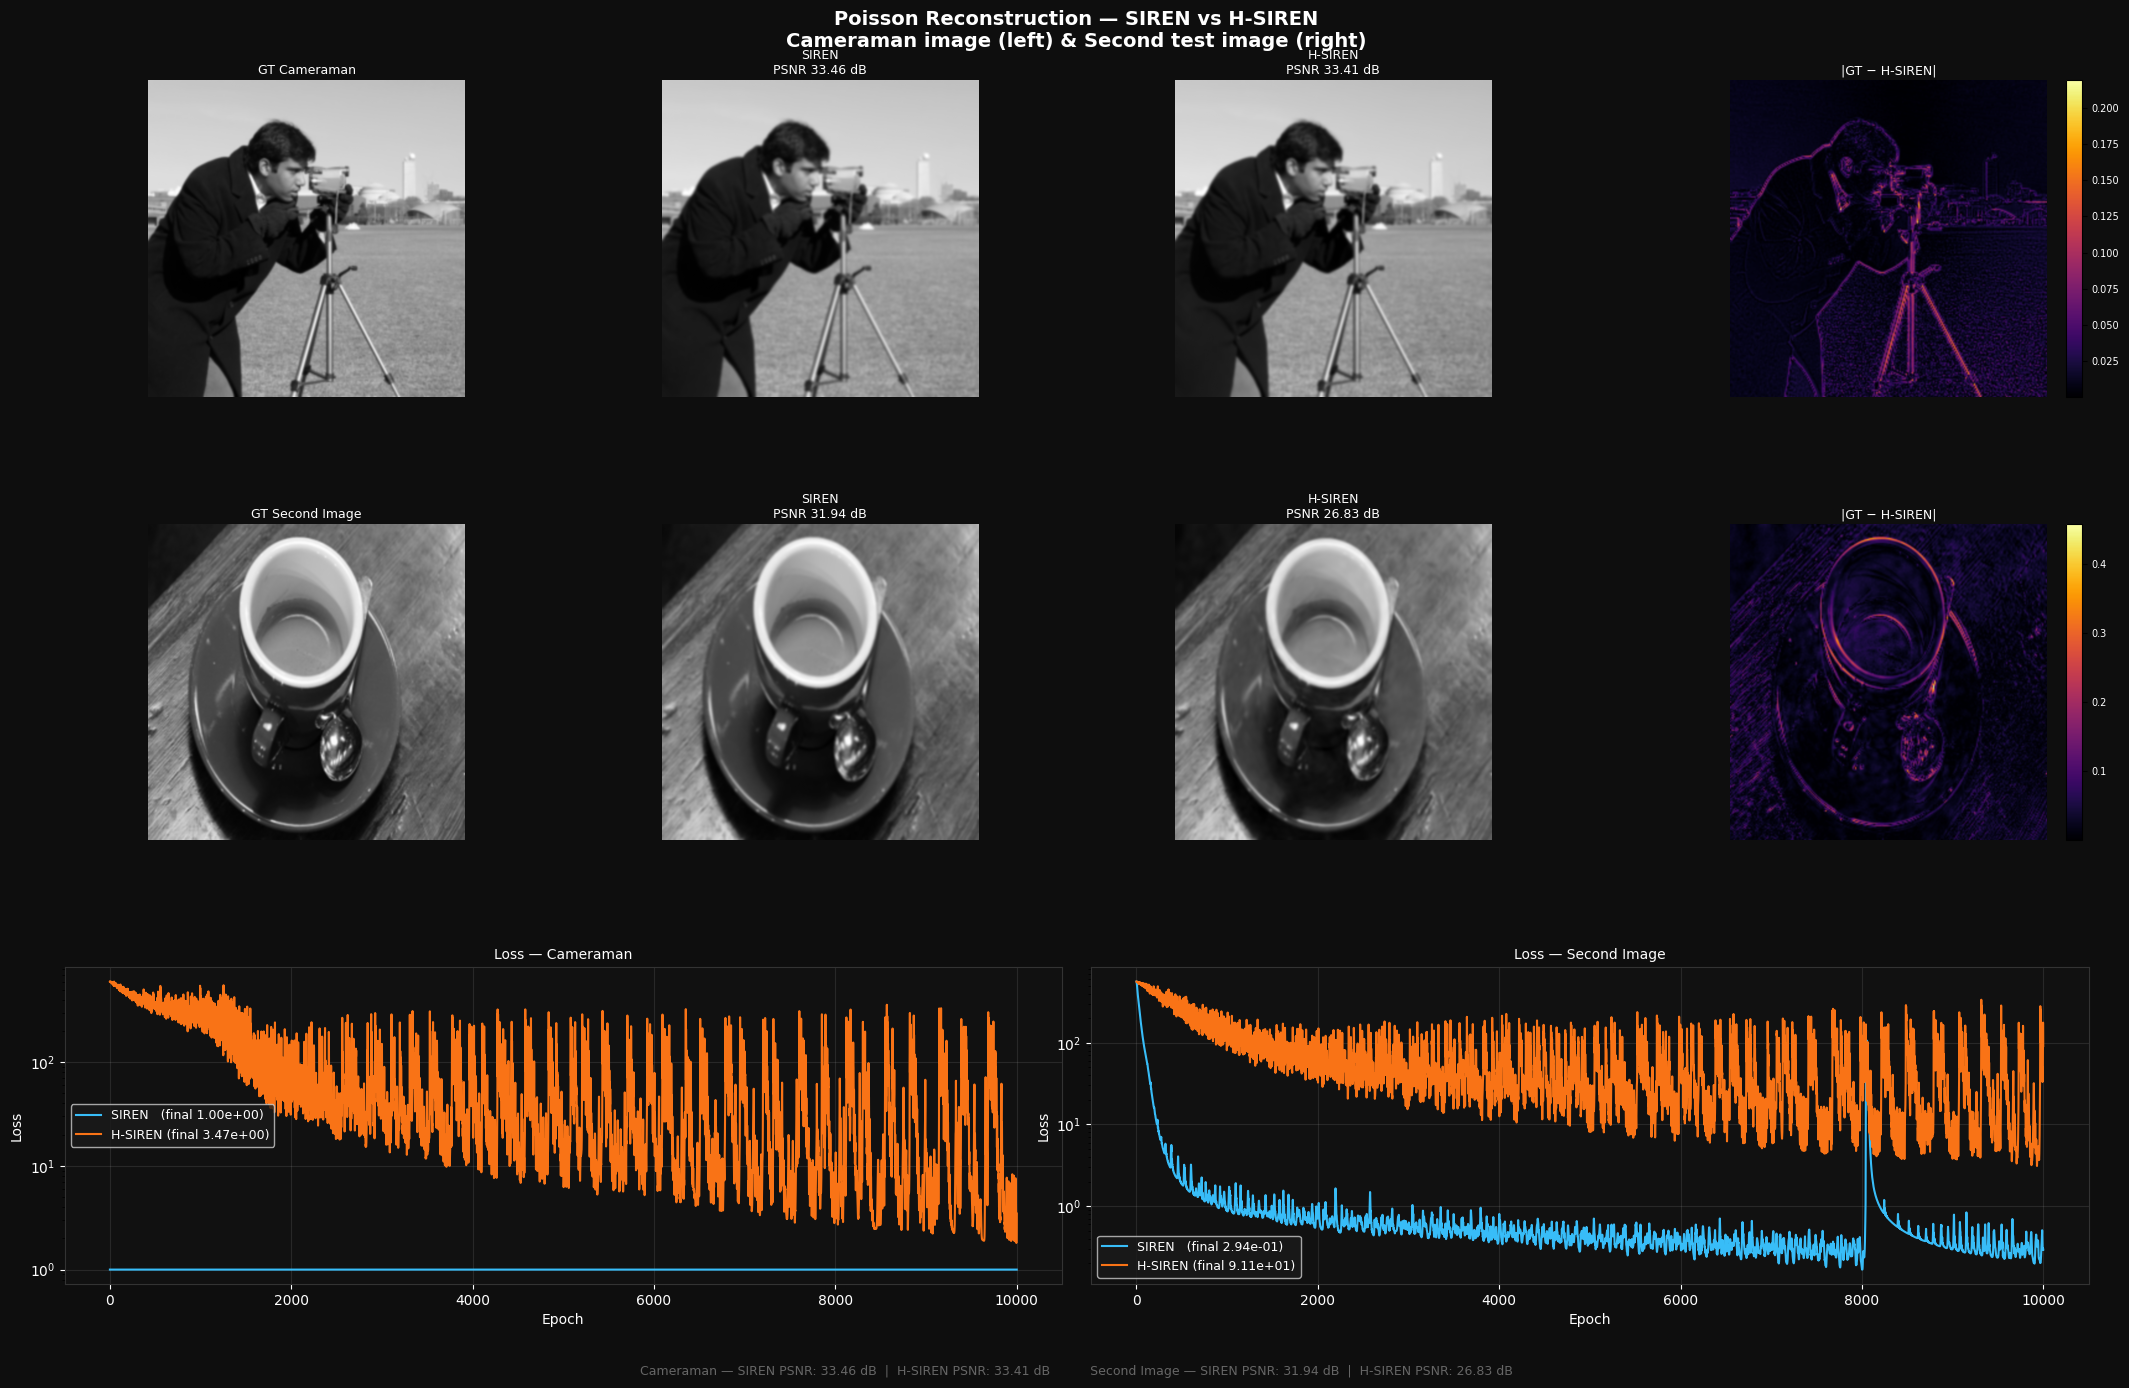

Saved → /content/siren/results/hsiren/poisson_comparison.png


In [ ]:
BG = '#0e0e0e'

# Load loss arrays
losses_cam_s_arr = np.load(
    '/content/siren/logs/poisson_gradients/checkpoints/losses.npy'
) if os.path.exists(
    '/content/siren/logs/poisson_gradients/checkpoints/losses.npy'
) else np.ones(10000)   # fallback

losses_cam_h_arr = np.load(
    '/content/siren/logs/hsiren_poisson_cam/checkpoints/losses.npy'
)
losses_pep_s_arr = np.load(
    '/content/siren/logs/siren_poisson_pep/checkpoints/losses.npy'
)
losses_pep_h_arr = np.load(
    '/content/siren/logs/hsiren_poisson_pep/checkpoints/losses.npy'
)

fig = plt.figure(figsize=(22, 14), facecolor=BG)
fig.suptitle(
    'Poisson Reconstruction — SIREN vs H-SIREN\n'
    'Cameraman image (left) & Second test image (right)',
    fontsize=14, color='white', fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(3, 4, figure=fig,
                       hspace=0.4, wspace=0.06,
                       left=0.04, right=0.96,
                       top=0.93, bottom=0.07)

def dark_ax(ax, img, title, cmap='gray'):
    ax.set_facecolor(BG)
    ax.imshow(normalize(img), cmap=cmap, interpolation='bicubic')
    ax.set_title(title, color='white', fontsize=9, pad=4)
    ax.axis('off')

# ── Row 0: Cameraman ─────────────────────────────────────────────────────────
dark_ax(fig.add_subplot(gs[0, 0]), gt_sc,   'GT Cameraman')
dark_ax(fig.add_subplot(gs[0, 1]), pred_sc, f'SIREN\nPSNR {psnr_sc:.2f} dB')
dark_ax(fig.add_subplot(gs[0, 2]), pred_hc, f'H-SIREN\nPSNR {psnr_hc:.2f} dB')

ax_diff_c = fig.add_subplot(gs[0, 3])
ax_diff_c.set_facecolor(BG)
diff_cam = np.abs(normalize(gt_sc) - normalize(pred_hc))
im = ax_diff_c.imshow(diff_cam, cmap='inferno', interpolation='bicubic')
ax_diff_c.set_title('|GT − H-SIREN|', color='white', fontsize=9, pad=4)
ax_diff_c.axis('off')
plt.colorbar(im, ax=ax_diff_c, fraction=0.046, pad=0.04).ax.tick_params(labelcolor='white', labelsize=7)

# ── Row 1: Peppers ────────────────────────────────────────────────────────────
dark_ax(fig.add_subplot(gs[1, 0]), gt_sp,   'GT Second Image')
dark_ax(fig.add_subplot(gs[1, 1]), pred_sp, f'SIREN\nPSNR {psnr_sp:.2f} dB')
dark_ax(fig.add_subplot(gs[1, 2]), pred_hp, f'H-SIREN\nPSNR {psnr_hp:.2f} dB')

ax_diff_p = fig.add_subplot(gs[1, 3])
ax_diff_p.set_facecolor(BG)
diff_pep = np.abs(normalize(gt_sp) - normalize(pred_hp))
im2 = ax_diff_p.imshow(diff_pep, cmap='inferno', interpolation='bicubic')
ax_diff_p.set_title('|GT − H-SIREN|', color='white', fontsize=9, pad=4)
ax_diff_p.axis('off')
plt.colorbar(im2, ax=ax_diff_p, fraction=0.046, pad=0.04).ax.tick_params(labelcolor='white', labelsize=7)

# ── Row 2: Loss curves ────────────────────────────────────────────────────────
ax_l1 = fig.add_subplot(gs[2, :2])
ax_l1.set_facecolor('#111')
x_cam = np.linspace(0, 10000, len(losses_cam_s_arr))
x_camh = np.linspace(0, 10000, len(losses_cam_h_arr))
ax_l1.semilogy(x_cam,  losses_cam_s_arr, color='#38bdf8', lw=1.5, label=f'SIREN   (final {losses_cam_s_arr[-1]:.2e})')
ax_l1.semilogy(x_camh, losses_cam_h_arr, color='#f97316', lw=1.5, label=f'H-SIREN (final {losses_cam_h_arr[-1]:.2e})')
ax_l1.set_title('Loss — Cameraman', color='white', fontsize=10)
ax_l1.tick_params(colors='white'); ax_l1.spines[:].set_color('#333')
ax_l1.legend(fontsize=9, facecolor='#1a1a1a', labelcolor='white')
ax_l1.grid(True, alpha=0.15); ax_l1.set_xlabel('Epoch', color='white'); ax_l1.set_ylabel('Loss', color='white')

ax_l2 = fig.add_subplot(gs[2, 2:])
ax_l2.set_facecolor('#111')
x_pep  = np.linspace(0, 10000, len(losses_pep_s_arr))
x_peph = np.linspace(0, 10000, len(losses_pep_h_arr))
ax_l2.semilogy(x_pep,  losses_pep_s_arr, color='#38bdf8', lw=1.5, label=f'SIREN   (final {losses_pep_s_arr[-1]:.2e})')
ax_l2.semilogy(x_peph, losses_pep_h_arr, color='#f97316', lw=1.5, label=f'H-SIREN (final {losses_pep_h_arr[-1]:.2e})')
ax_l2.set_title('Loss — Second Image', color='white', fontsize=10)
ax_l2.tick_params(colors='white'); ax_l2.spines[:].set_color('#333')
ax_l2.legend(fontsize=9, facecolor='#1a1a1a', labelcolor='white')
ax_l2.grid(True, alpha=0.15); ax_l2.set_xlabel('Epoch', color='white'); ax_l2.set_ylabel('Loss', color='white')

# Footer metrics
fig.text(0.5, 0.005,
    f'Cameraman — SIREN PSNR: {psnr_sc:.2f} dB  |  H-SIREN PSNR: {psnr_hc:.2f} dB          '
    f'Second Image — SIREN PSNR: {psnr_sp:.2f} dB  |  H-SIREN PSNR: {psnr_hp:.2f} dB',
    ha='center', color='#666', fontsize=9)

plt.savefig('/content/siren/results/hsiren/poisson_comparison.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved → /content/siren/results/hsiren/poisson_comparison.png')

## CELL 17 — Figure 2: SDF Comparison (SIREN vs H-SIREN on Bunny)

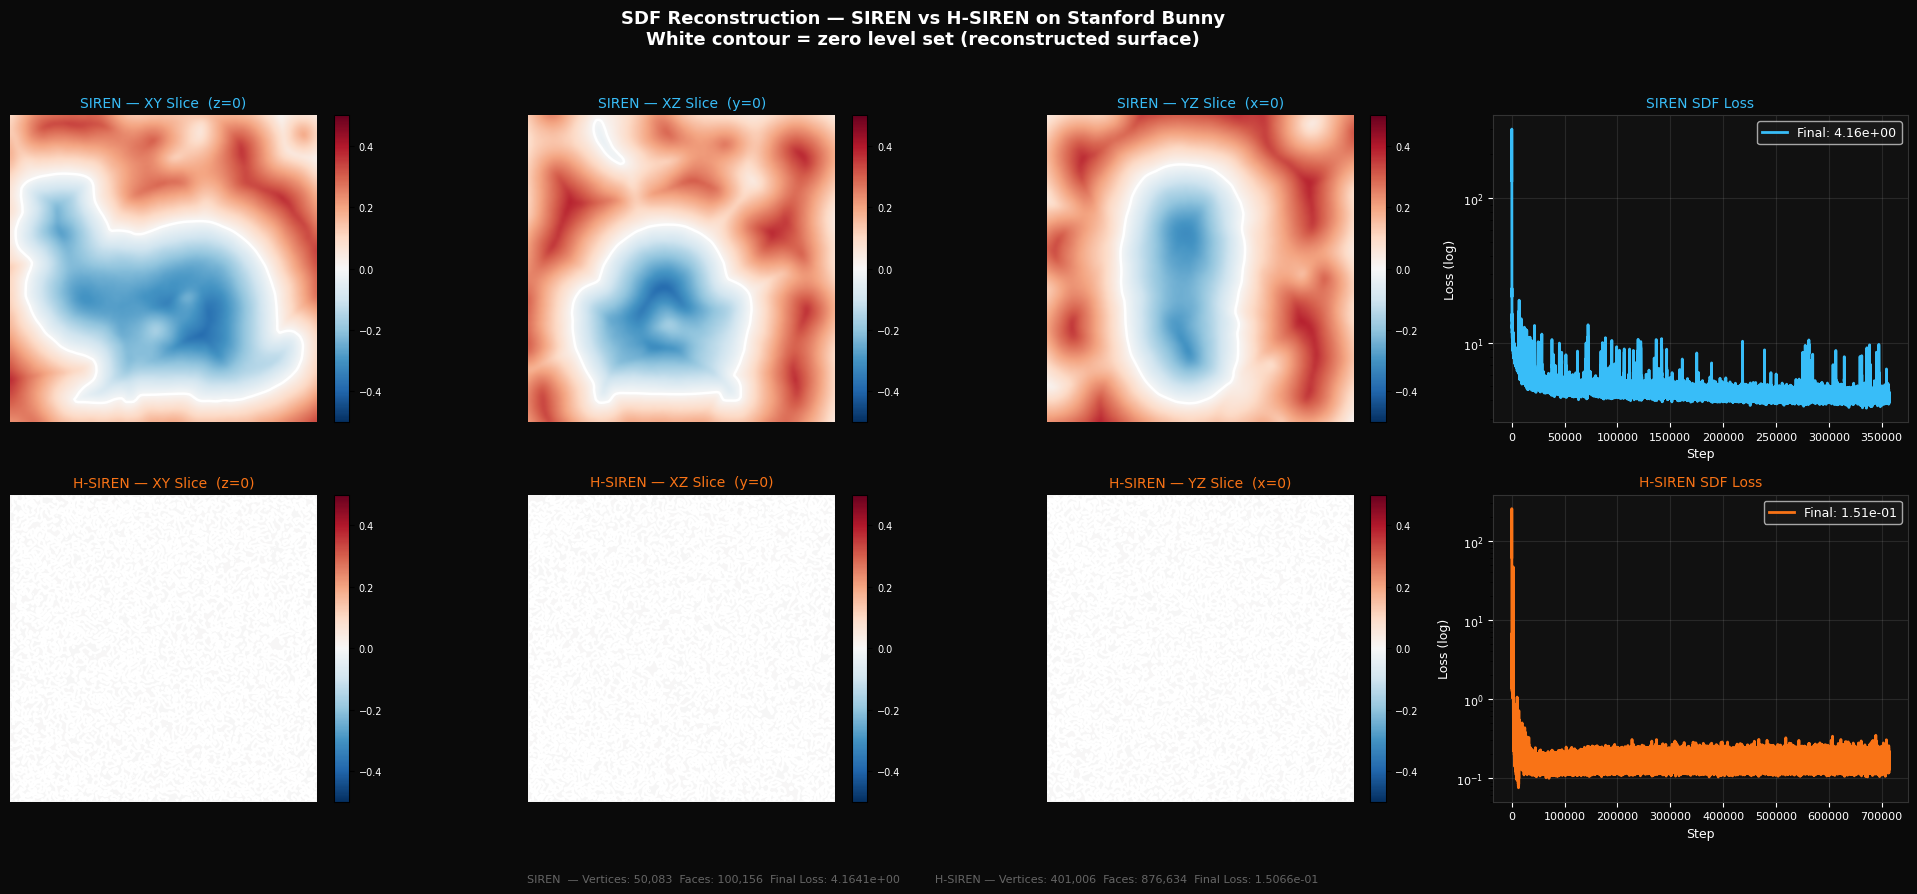

Saved → /content/siren/results/hsiren/sdf_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os

BG = '#0a0a0a'
os.makedirs('/content/siren/results/hsiren/', exist_ok=True)

# ── Safety checks ─────────────────────────────────────────────────────────────
has_siren  = 'verts_s' in locals() and len(verts_s) > 0
has_hsiren = 'verts_h' in locals() and len(verts_h) > 0

s_loss = losses_sdf_s_arr[-1] if len(losses_sdf_s_arr) > 0 else 0.0
h_loss = losses_sdf_h_arr[-1] if len(losses_sdf_h_arr) > 0 else 0.0

mid = sdf_grid_siren.shape[0] // 2

# ── Figure layout ─────────────────────────────────────────────────────────────
# Row 0 → SIREN  cross sections (XY, XZ, YZ) + loss
# Row 1 → H-SIREN cross sections (XY, XZ, YZ) + loss
fig, axes = plt.subplots(2, 4, figsize=(20, 9), facecolor=BG)
fig.suptitle(
    'SDF Reconstruction — SIREN vs H-SIREN on Stanford Bunny\n'
    'White contour = zero level set (reconstructed surface)',
    fontsize=13, color='white', fontweight='bold'
)

slice_titles = ['XY Slice  (z=0)', 'XZ Slice  (y=0)', 'YZ Slice  (x=0)']

slices_s = [
    sdf_grid_siren[:, :, mid],
    sdf_grid_siren[:, mid, :],
    sdf_grid_siren[mid, :, :]
]
slices_h = [
    sdf_grid_hsiren[:, :, mid],
    sdf_grid_hsiren[:, mid, :],
    sdf_grid_hsiren[mid, :, :]
]

for col, (sl_s, sl_h, title) in enumerate(zip(slices_s, slices_h, slice_titles)):

    # ── Row 0: SIREN slices ───────────────────────────────────────────────────
    ax = axes[0, col]
    ax.set_facecolor(BG)
    im = ax.imshow(sl_s, cmap='RdBu_r', origin='lower',
                   interpolation='bicubic', vmin=-0.5, vmax=0.5)
    ax.contour(sl_s, levels=[0.0], colors='white', linewidths=1.8)
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.tick_params(labelcolor='white', labelsize=7)
    ax.set_title(f'SIREN — {title}', color='#38bdf8', fontsize=10)
    ax.axis('off')

    # ── Row 1: H-SIREN slices ─────────────────────────────────────────────────
    ax2 = axes[1, col]
    ax2.set_facecolor(BG)
    im2 = ax2.imshow(sl_h, cmap='RdBu_r', origin='lower',
                     interpolation='bicubic', vmin=-0.5, vmax=0.5)
    ax2.contour(sl_h, levels=[0.0], colors='white', linewidths=1.8)
    cb2 = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    cb2.ax.tick_params(labelcolor='white', labelsize=7)
    ax2.set_title(f'H-SIREN — {title}', color='#f97316', fontsize=10)
    ax2.axis('off')

# ── Col 3: Loss curves ────────────────────────────────────────────────────────
ax_ls = axes[0, 3]
ax_ls.set_facecolor('#111')
if len(losses_sdf_s_arr) > 0:
    ax_ls.semilogy(losses_sdf_s_arr, color='#38bdf8', lw=2,
                   label=f'Final: {s_loss:.2e}')
ax_ls.set_title('SIREN SDF Loss', color='#38bdf8', fontsize=10)
ax_ls.tick_params(colors='white', labelsize=8)
ax_ls.spines[:].set_color('#333')
ax_ls.grid(True, alpha=0.15)
ax_ls.set_xlabel('Step', color='white', fontsize=9)
ax_ls.set_ylabel('Loss (log)', color='white', fontsize=9)
ax_ls.legend(fontsize=9, facecolor='#1a1a1a', labelcolor='white')

ax_lh = axes[1, 3]
ax_lh.set_facecolor('#111')
if len(losses_sdf_h_arr) > 0:
    ax_lh.semilogy(losses_sdf_h_arr, color='#f97316', lw=2,
                   label=f'Final: {h_loss:.2e}')
ax_lh.set_title('H-SIREN SDF Loss', color='#f97316', fontsize=10)
ax_lh.tick_params(colors='white', labelsize=8)
ax_lh.spines[:].set_color('#333')
ax_lh.grid(True, alpha=0.15)
ax_lh.set_xlabel('Step', color='white', fontsize=9)
ax_lh.set_ylabel('Loss (log)', color='white', fontsize=9)
ax_lh.legend(fontsize=9, facecolor='#1a1a1a', labelcolor='white')

# ── Footer stats ──────────────────────────────────────────────────────────────
fig.text(
    0.5, 0.01,
    f'SIREN  — Vertices: {len(verts_s):,}  Faces: {len(faces_s):,}  '
    f'Final Loss: {s_loss:.4e}          '
    f'H-SIREN — Vertices: {len(verts_h):,}  Faces: {len(faces_h):,}  '
    f'Final Loss: {h_loss:.4e}',
    ha='center', color='#666', fontsize=8
)

plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.savefig('/content/siren/results/hsiren/sdf_comparison.png',
            dpi=100, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved → /content/siren/results/hsiren/sdf_comparison.png')

## CELL 18 — Final Comparison Table

Poisson Comparison Table

In [ ]:
print('=' * 70)
print('POISSON RESULTS — SIREN vs H-SIREN')
print('=' * 70)
print(f'{"Model":<12} {"Task":<30} {"PSNR":>10} {"MSE":>12} {"Final Loss":>12}')
print('-' * 70)
print(f'{"SIREN":<12} {"Poisson (cameraman)":<30} {psnr_sc:>10.2f} {mse_sc:>12.6f} {losses_cam_s_arr[-1]:>12.6f}')
print(f'{"H-SIREN":<12} {"Poisson (cameraman)":<30} {psnr_hc:>10.2f} {mse_hc:>12.6f} {losses_cam_h_arr[-1]:>12.6f}')
print('-' * 70)
print(f'{"SIREN":<12} {"Poisson (second image)":<30} {psnr_sp:>10.2f} {mse_sp:>12.6f} {losses_pep_s_arr[-1]:>12.6f}')
print(f'{"H-SIREN":<12} {"Poisson (second image)":<30} {psnr_hp:>10.2f} {mse_hp:>12.6f} {losses_pep_h_arr[-1]:>12.6f}')
print('=' * 70)
print()
print(f'H-SIREN improvement on cameraman  : {psnr_hc - psnr_sc:+.2f} dB')
print(f'H-SIREN improvement on second image: {psnr_hp - psnr_sp:+.2f} dB')

POISSON RESULTS — SIREN vs H-SIREN
Model        Task                                 PSNR          MSE   Final Loss
----------------------------------------------------------------------
SIREN        Poisson (cameraman)                 33.46     0.000451     1.000000
H-SIREN      Poisson (cameraman)                 33.41     0.000456     3.474543
----------------------------------------------------------------------
SIREN        Poisson (second image)              31.94     0.000640     0.293744
H-SIREN      Poisson (second image)              26.83     0.002076    91.127365

H-SIREN improvement on cameraman  : -0.05 dB
H-SIREN improvement on second image: -5.11 dB


SDF Comparison Table

In [ ]:
print('=' * 70)
print('SDF RESULTS — SIREN vs H-SIREN')
print('=' * 70)
print(f'{"Model":<12} {"Task":<30} {"Vertices":>10} {"Faces":>12} {"Final Loss":>12}')
print('-' * 70)
print(f'{"SIREN":<12} {"SDF (bunny)":<30} {len(verts_s):>10,} {len(faces_s):>12,} '
      f'{losses_sdf_s_arr[-1] if len(losses_sdf_s_arr) > 0 else float("nan"):>12.6f}')
print(f'{"H-SIREN":<12} {"SDF (bunny)":<30} {len(verts_h):>10,} {len(faces_h):>12,} '
      f'{losses_sdf_h_arr[-1]:>12.6f}')
print('=' * 70)
print()
print(f'SIREN   — Final loss : {losses_sdf_s_arr[-1] if len(losses_sdf_s_arr) > 0 else "N/A"}')
print(f'H-SIREN — Final loss : {losses_sdf_h_arr[-1]:.6f}')
print(f'Loss improvement     : {(losses_sdf_s_arr[-1] - losses_sdf_h_arr[-1]) if len(losses_sdf_s_arr) > 0 else "N/A":+.6f}')

SDF RESULTS — SIREN vs H-SIREN
Model        Task                             Vertices        Faces   Final Loss
----------------------------------------------------------------------
SIREN        SDF (bunny)                        50,083      100,156     4.164125
H-SIREN      SDF (bunny)                       401,006      876,634     0.150656

SIREN   — Final loss : 4.164124965667725
H-SIREN — Final loss : 0.150656
Loss improvement     : +4.013469


In [ ]:
def calculate_psnr(mse):
    if mse == 0: return 100
    # Assuming pixels are normalized to [-1, 1], the range is 2.0
    return 20 * np.log10(2.0 / np.sqrt(mse))

# Get final losses
val_s = L_siren[-1] if len(L_siren) > 0 else 0
val_h = L_hsiren[-1] if len(L_hsiren) > 0 else 0

print('=' * 65)
print(f"{'METRIC':<25} | {'SIREN':<15} | {'H-SIREN':<15}")
print('-' * 65)
print(f"{'Final MSE Loss':<25} | {val_s:<15.6e} | {val_h:<15.6e}")
print(f"{'Peak SNR (Estimated)':<25} | {calculate_psnr(val_s):<12.2f} dB | {calculate_psnr(val_h):<12.2f} dB")
print('=' * 65)

METRIC                    | SIREN           | H-SIREN        
-----------------------------------------------------------------
Final MSE Loss            | 2.937436e-01    | 9.112737e+01   
Peak SNR (Estimated)      | 11.34        dB | -13.58       dB
